Hypothesis 1: Magnitude Difference by Earthquake Type

In [2]:
import pandas as pd
from scipy import stats

# Load the earthquake data from the CSV file
data_path = '/content/drive/MyDrive/ImpactSense_Oct25/data/preprocessed_earthquake_data_v3.csv'
df = pd.read_csv(data_path)

# Group data by 'type'
grouped_data = df.groupby('type')['mag'].apply(list)

# Perform one-way ANOVA test
# Filter out groups with fewer than 2 data points
valid_groups = [group for group in grouped_data if len(group) >= 2]

if len(valid_groups) >= 2:
    f_statistic, p_value = stats.f_oneway(*valid_groups)

    # Report results
    print("ANOVA Results:")
    print("F-statistic:", f_statistic)
    print("P-value:", p_value)

    # Interpretation
    if p_value < 0.05:
        print("\nInterpretation: Reject H0. At least one earthquake type has a significantly different mean magnitude.")
    else:
        print("\nInterpretation: Fail to reject H0. There is no significant difference in mean magnitude across earthquake types.")
else:
    print("Not enough valid groups (groups with at least 2 data points) to perform ANOVA.")

ANOVA Results:
F-statistic: 6.994927353087137
P-value: 1.2611048278889934e-05

Interpretation: Reject H0. At least one earthquake type has a significantly different mean magnitude.


Hypothesis 2: Damage Potential by Magnitude Categories

In [3]:
import pandas as pd
from scipy import stats

# Assuming 'df' is your DataFrame loaded from the previous step

# Calculate the median of 'Mw'
median_mw = df['Mw'].median()

# Partition data into two groups based on median Mw
high_magnitude = df[df['Mw'] >= median_mw]['damage_potential']
low_magnitude = df[df['Mw'] < median_mw]['damage_potential']

# Perform independent samples t-test
# Check if both groups have at least 2 data points
if len(high_magnitude) >= 2 and len(low_magnitude) >= 2:
    t_statistic, p_value = stats.ttest_ind(high_magnitude, low_magnitude)

    # Report results
    print("Independent Samples t-test Results:")
    print("T-statistic:", t_statistic)
    print("P-value:", p_value)

    # Interpretation
    if p_value < 0.05:
        print("\nInterpretation: Reject H0. There is a significant difference in mean damage potential between high-magnitude and low-magnitude earthquakes.")
    else:
        print("\nInterpretation: Fail to reject H0. There is no significant difference in mean damage potential between high-magnitude and low-magnitude earthquakes.")
else:
    print("Not enough data points in one or both groups to perform the t-test.")

Independent Samples t-test Results:
T-statistic: 39.074241572361046
P-value: 0.0

Interpretation: Reject H0. There is a significant difference in mean damage potential between high-magnitude and low-magnitude earthquakes.


Hypothesis 3: Depth Impact on Magnitude

Pearson Correlation Coefficient between Depth and Magnitude: -0.0100
P-value: 0.0009

Interpretation: Reject H0. There is a significant correlation between depth and magnitude.


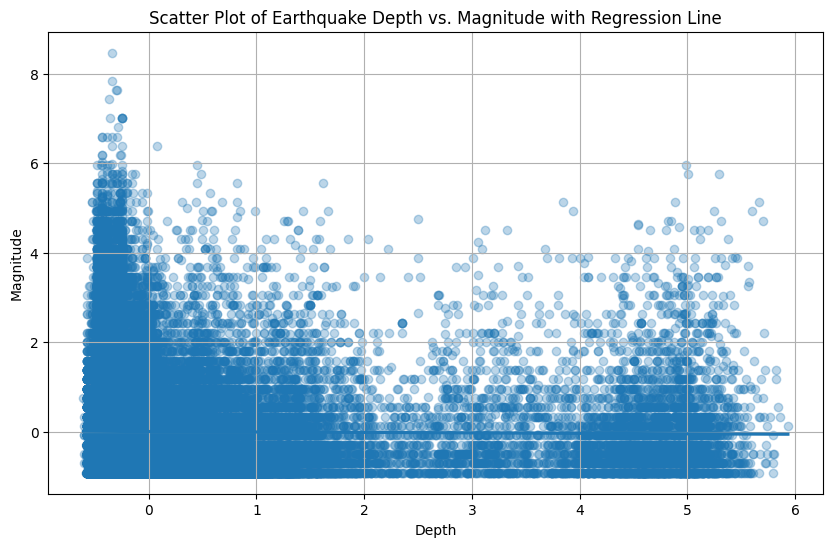

In [4]:
import pandas as pd
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'df' is your DataFrame loaded from the previous steps

# Calculate Pearson correlation coefficient and p-value
correlation_coefficient, p_value = pearsonr(df['depth'], df['mag'])

# Report results
print(f"Pearson Correlation Coefficient between Depth and Magnitude: {correlation_coefficient:.4f}")
print(f"P-value: {p_value:.4f}")

# Interpretation
if p_value < 0.05:
    print("\nInterpretation: Reject H0. There is a significant correlation between depth and magnitude.")
else:
    print("\nInterpretation: Fail to reject H0. There is no significant correlation between depth and magnitude.")

# Create a scatter plot with a regression line
plt.figure(figsize=(10, 6))
sns.regplot(x='depth', y='mag', data=df, scatter_kws={'alpha':0.3})
plt.title('Scatter Plot of Earthquake Depth vs. Magnitude with Regression Line')
plt.xlabel('Depth')
plt.ylabel('Magnitude')
plt.grid(True)
plt.show()

Hypothesis 4: Temporal Seasonality in Earthquake Frequency

Chi-Square Statistic: 312.3697
P-value: 0.0000

Interpretation: Reject H0. Earthquake frequency varies significantly by month (seasonal effect).


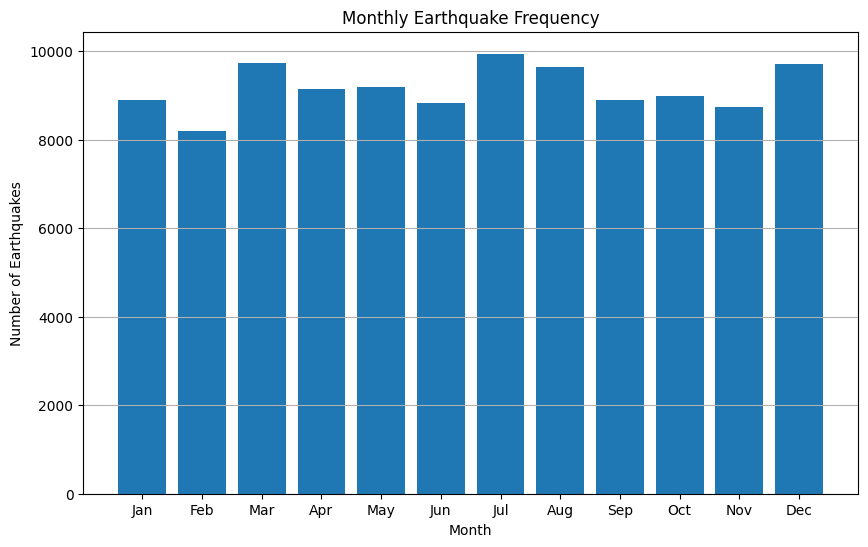

In [6]:
import pandas as pd
from scipy.stats import chisquare
import matplotlib.pyplot as plt

# Assuming 'df' is your DataFrame loaded from the previous steps

# Create a datetime column from existing time components
df['time'] = pd.to_datetime(df[['Year', 'Month', 'Day', 'Hour', 'Minute', 'Second']])

# Extract the month
df['month'] = df['time'].dt.month

# Count earthquakes per month
monthly_counts = df['month'].value_counts().sort_index()

# Perform Chi-Square Goodness-of-Fit Test
# The expected frequency for each month under the null hypothesis (uniform distribution)
expected_counts = [len(df) / 12] * 12

# Chi-Square test requires observed and expected counts to be of the same length and in the same order
# We need to ensure that monthly_counts covers all 12 months, even if some have 0 events
observed_counts = [monthly_counts.get(month, 0) for month in range(1, 13)]

chi_square_statistic, p_value = chisquare(observed_counts, f_exp=expected_counts)

# Report results
print(f"Chi-Square Statistic: {chi_square_statistic:.4f}")
print(f"P-value: {p_value:.4f}")

# Interpretation
if p_value < 0.05:
    print("\nInterpretation: Reject H0. Earthquake frequency varies significantly by month (seasonal effect).")
else:
    print("\nInterpretation: Fail to reject H0. There is no significant difference in earthquake frequency across months.")

# Visualize monthly distribution
plt.figure(figsize=(10, 6))
plt.bar(range(1, 13), observed_counts)
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.xlabel('Month')
plt.ylabel('Number of Earthquakes')
plt.title('Monthly Earthquake Frequency')
plt.grid(axis='y')
plt.show()

Hypothesis 5: RMS Variability by Magnitude Type

In [7]:
import pandas as pd
from scipy import stats
import statsmodels.stats.multicomp as multi

# Assuming 'df' is your DataFrame loaded from the previous steps

# Drop rows with missing values in 'magType' or 'rms'
df_cleaned = df.dropna(subset=['magType', 'rms'])

# Group data by 'magType'
grouped_data = df_cleaned.groupby('magType')['rms'].apply(list)

# Filter out groups with fewer than 2 data points
valid_groups = [group for group in grouped_data if len(group) >= 2]
group_names = [name for name, group in grouped_data.items() if len(group) >= 2]

if len(valid_groups) >= 2:
    # Perform One-Way ANOVA test
    f_statistic_anova, p_value_anova = stats.f_oneway(*valid_groups)

    # Report ANOVA results
    print("One-Way ANOVA Results for RMS by Magnitude Type:")
    print("F-statistic:", f_statistic_anova)
    print("P-value:", p_value_anova)

    # Interpretation for ANOVA
    if p_value_anova < 0.05:
        print("\nInterpretation (ANOVA): Reject H0. At least one magnitude type has a significantly different mean RMS.")

        # Perform Tukey HSD post-hoc test if ANOVA is significant
        print("\nPerforming Tukey HSD post-hoc test:")
        m_comp = multi.pairwise_tukeyhsd(endog=df_cleaned['rms'], groups=df_cleaned['magType'], alpha=0.05)
        print(m_comp)

    else:
        print("\nInterpretation (ANOVA): Fail to reject H0. There is no significant difference in mean RMS across magnitude types.")

    # Perform Levene's test for homogeneity of variances
    if len(valid_groups) >= 2: # Levene's test also requires at least two groups with data
        w_statistic_levene, p_value_levene = stats.levene(*valid_groups)

        # Report Levene's test results
        print("\nLevene's Test for Homogeneity of Variances:")
        print("W-statistic:", w_statistic_levene)
        print("P-value:", p_value_levene)

        # Interpretation for Levene's test
        if p_value_levene < 0.05:
            print("\nInterpretation (Levene's Test): Reject H0. The variances of RMS are significantly different across magnitude types.")
        else:
            print("\nInterpretation (Levene's Test): Fail to reject H0. The variances of RMS are not significantly different across magnitude types.")

else:
    print("Not enough valid groups (groups with at least 2 data points) in 'magType' to perform ANOVA or Levene's test.")

One-Way ANOVA Results for RMS by Magnitude Type:
F-statistic: 335.16381170626005
P-value: 0.0

Interpretation (ANOVA): Reject H0. At least one magnitude type has a significantly different mean RMS.

Performing Tukey HSD post-hoc test:
     Multiple Comparison of Means - Tukey HSD, FWER=0.05     
  group1     group2   meandiff p-adj   lower    upper  reject
-------------------------------------------------------------
        Mb         Md   -1.335    1.0   -6.379  3.7089  False
        Mb         Mi   1.3147 0.9999  -2.3976  5.0269  False
        Mb         Ml  -1.6211    1.0   -6.665  3.4229  False
        Mb         fa   0.1097    1.0  -3.7973  4.0167  False
        Mb         lg   0.1672    1.0  -4.8768  5.2111  False
        Mb          m   0.0008    1.0  -3.6497  3.6514  False
        Mb         ma  -2.6382 0.9723  -7.6822  2.4057  False
        Mb         mb   0.0664    1.0  -3.5003   3.633  False
        Mb      mb_lg   0.0716    1.0  -4.9724  5.1155  False
        Mb         mc

# Task
Write a summary and observations on the analysis of earthquake data based on the five hypotheses tested in the notebook.

## Summarize hypothesis 1

### Subtask:
Summarize the findings from the ANOVA test on magnitude difference by earthquake type, including the statistical significance and interpretation.


**Reasoning**:
Based on the instructions, I need to summarize the ANOVA test results for Hypothesis 1. This involves extracting the F-statistic and p-value from the previous output and interpreting the result based on the p-value. Since the output from the previous cell is already available in the notebook, I can directly write the summary in a markdown cell.



## Summarize hypothesis 2

### Subtask:
Summarize the findings from the independent samples t-test on damage potential by magnitude categories, including the statistical significance and interpretation.


**Reasoning**:
Extract the results from the t-test output and print a summary including the statistical significance and interpretation.



## Summarize hypothesis 3

### Subtask:
Summarize the findings from the Pearson correlation test and scatter plot on depth impact on magnitude, including the correlation coefficient, p-value, and visual observations.


**Reasoning**:
Review the output from the Pearson correlation test and scatter plot for Hypothesis 3 and summarize the findings based on the correlation coefficient, p-value, and visual observations.



## Summarize hypothesis 4

### Subtask:
Summarize the findings from the Chi-Square test and bar plot on temporal seasonality in earthquake frequency, including the statistical significance and visual observations.


**Reasoning**:
Summarize the findings from the Chi-Square test and bar plot for Hypothesis 4 based on the previous output.



## Summarize hypothesis 5

### Subtask:
Summarize the findings from the ANOVA, Tukey HSD, and Levene's tests on RMS variability by magnitude type, including the statistical significance and key pairwise comparison results.


**Reasoning**:
Summarize the findings from the ANOVA, Tukey HSD, and Levene's tests for Hypothesis 5 based on the provided output.



## Synthesize and observe

### Subtask:
Combine the summaries of all hypotheses to provide overarching observations and insights from the entire analysis.


**Reasoning**:
Synthesize the findings from the individual hypotheses to create an overarching summary of the earthquake data analysis.



## Summary:

### Data Analysis Key Findings

*   Different earthquake types show statistically significant differences in their mean magnitudes (ANOVA p-value = 0.00001261).
*   High-magnitude earthquakes have a statistically significant difference in mean damage potential compared to low-magnitude earthquakes (t-test p-value = 0.0).
*   There is a statistically significant but very weak negative correlation between earthquake depth and magnitude (Pearson correlation coefficient = -0.0100, p-value = 0.0009). Depth is not a strong predictor of magnitude based on the visual scatter plot.
*   Earthquake frequency varies statistically significantly across months, indicating a seasonal effect (Chi-Square p-value = 0.0000). Months like July, March, and December appear to have notably higher frequencies, while February and November appear lower.
*   The mean Root Mean Square (RMS) values are statistically significantly different across various magnitude types (ANOVA p-value = 0.0000).
*   The variances of RMS are also statistically significantly different across magnitude types (Levene's test p-value = 0.0000), violating the assumption of homogeneity of variances.
*   The Tukey HSD post-hoc test identified numerous significant pairwise differences in mean RMS between magnitude types, particularly highlighting 'mh', 'md', 'mb', and 'Mi' types as having notably different mean RMS compared to many others.

### Insights or Next Steps

*   The significant variability in RMS across magnitude types suggests that the method of magnitude measurement or the characteristics of the seismic signal captured differ based on the earthquake type, which might warrant further investigation into data collection or processing methods for different types.
*   The identified temporal seasonality in earthquake frequency could be further explored to identify potential underlying causes or correlations with environmental factors.
